# Aggregation kinetics — the efficiency demo

**The task:** analyse a single amyloid aggregation curve (the sigmoidal ThT / polymer-mass
trace of a protein polymerising into fibrils) and report *what the data can and cannot tell
you* about the three microscopic rate constants.

**The control.** A frontier LLM agent, unaided, took **12.2 minutes / 28 turns / \$1.63 /
six iterative scripts** to correctly conclude that the three constants are *not* separable
from one curve (`design/automated_scientist/runs/000000008`).

**NUDGE** (`NUDGE-METHOD-013`) returns the same honest answer in **one deterministic call** —
the identifiable composites κ, λ *plus a **measured** proof that the individual constants are
non-identifiable* (an exact gauge symmetry, Fisher condition number → ∞). It never reports a
false-precise rate constant from insufficient data.

The model is the filament master equation reduced to its principal moments
(Knowles 2009 / Cohen 2013 / Meisl 2016 / Michaels 2020):

$$\frac{dP}{dt}=k_n\,m^{n_c}+k_2\,m^{n_2}M,\qquad \frac{dM}{dt}=2\,k_+\,m\,P,\qquad m=m_{tot}-M$$

integrated by a self-contained differentiable RK4 `lax.scan` — touching **neither `fit.py`
nor `core/`** (the frozen core).

ground truth: {'k_n': 0.0005, 'k_plus': 0.1, 'k_2': 5.0, 'n_c': 2.0, 'n_2': 2.0, 'm_tot': 1.0}
true composites: lambda = 0.01  kappa = 1.0


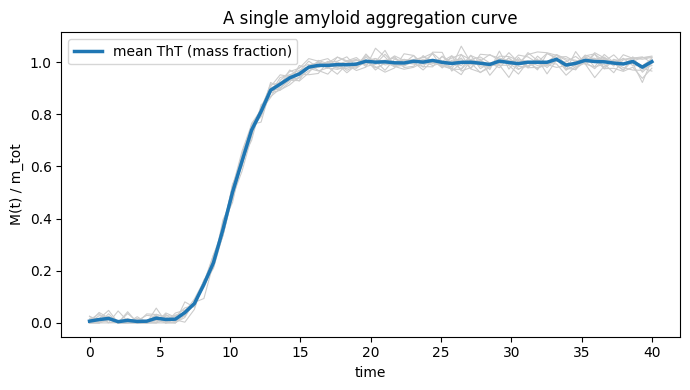

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nudge.mechanisms import fibrillization as fib

# a synthetic aggregation curve with KNOWN kinetics (secondary-nucleation dominated:
# k_n=5e-4, k_+=0.1, k_2=5.0  ->  lambda=0.01, kappa=1.0, matching the control agent's case)
curve = fib.simulate_aggregation_curve(seed=0)
gt = curve.ground_truth
print("ground truth:", {k: gt[k] for k in ('k_n','k_plus','k_2','n_c','n_2','m_tot')})
print("true composites: lambda =", gt['lambda'], " kappa =", gt['kappa'])

fig, ax = plt.subplots(figsize=(7,4))
for r in curve.signal:
    ax.plot(curve.t_obs, r, color='0.8', lw=0.8)
ax.plot(curve.t_obs, curve.mean, color='C0', lw=2.5, label='mean ThT (mass fraction)')
ax.set_xlabel('time'); ax.set_ylabel('M(t) / m_tot'); ax.set_title('A single amyloid aggregation curve')
ax.legend(); fig.tight_layout()

## One call: composites identified, individual constants abstained-on

`attribute_aggregation` fits the curve and hands the Fisher/Laplace curvature on
`(log k_n, log k_+, log k_2)` to NUDGE's identifiability guard.

In [2]:
res = fib.attribute_aggregation(curve, steps=500)
ident = res.identifiability

print("CALL:", res.call)
print(f"  IDENTIFIABLE composites:  kappa = {res.kappa:.3g}  (CI {tuple(round(x,3) for x in res.fit.kappa_ci)})")
print(f"                            lambda = {res.lam:.3g}  (CI {tuple(round(x,4) for x in res.fit.lam_ci)})")
print(f"  individual k_n,k_+,k_2 identifiable?  {res.individual_k_identifiable}")
print(f"  Fisher condition number = {ident.cond_number:.3g}   (-> infinity at the exact gauge)")
print(f"  null direction (log k_n, log k_+, log k_2) = {np.round(ident.null_direction,3).tolist()}")
print(f"  numerical gauge check (100x k_+ rescale) = {ident.gauge_check:.2g}  (~0 => exact symmetry)")

# --- in-notebook ground-truth assertions (this notebook fails loudly if the claim breaks) ---
assert res.kappa == 0 or abs(res.kappa - 1.0) < 0.1        # kappa recovered
assert abs(res.lam - 0.01) < 0.006                          # lambda recovered
assert res.individual_k_identifiable is False               # the three k's ABSTAINED on
assert ident.cond_number > 1e3                              # measured near-singular curvature
assert ident.gauge_check < 1e-6                             # the gauge symmetry is exact
print("\nasserts passed: composites recovered; individual constants correctly abstained on.")

CALL: composites-identified
  IDENTIFIABLE composites:  kappa = 1  (CI (0.985, 1.018))
                            lambda = 0.00991  (CI (0.0093, 0.0106))
  individual k_n,k_+,k_2 identifiable?  False
  Fisher condition number = inf   (-> infinity at the exact gauge)
  null direction (log k_n, log k_+, log k_2) = [0.577, -0.577, 0.577]
  numerical gauge check (100x k_+ rescale) = 1.1e-16  (~0 => exact symmetry)

asserts passed: composites recovered; individual constants correctly abstained on.


## Why: the exact gauge symmetry

The moment model has an **exact continuous symmetry**: scaling
$(k_n, k_+, k_2)\to(k_n/\alpha,\ \alpha\,k_+,\ k_2/\alpha)$ leaves the mass-fraction curve
*identical* for any $\alpha>0$. So a whole 1-parameter family of microscopic rate constants
fits the curve equally well — the individual constants are provably non-identifiable, and the
null direction is $(+\log k_n,\,-\log k_+,\,+\log k_2)$ (the `[+0.577, -0.577, +0.577]` above).
Below: three wildly different $(k_n,k_+,k_2)$ triples on the gauge orbit — **the curves lie
exactly on top of each other**.

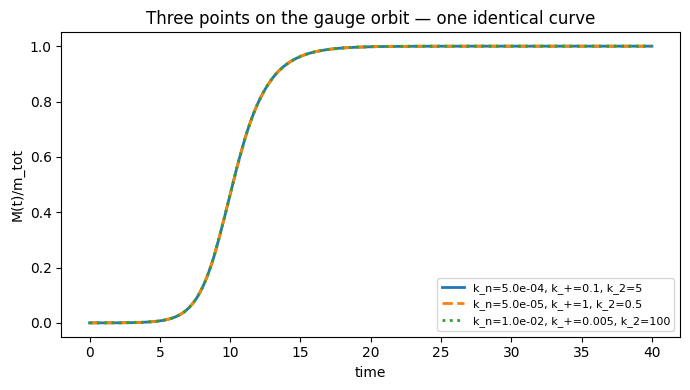

In [3]:
t = np.linspace(0, 40, 200)
n_steps = 4000; dt = 0.01
import jax.numpy as jnp
obs_idx = jnp.asarray(np.clip(np.round(t/dt).astype(int), 0, n_steps))
kw = dict(m_tot=1.0, dt=dt, n_steps=n_steps, obs_idx=obs_idx, n_c=2.0, n_2=2.0)
fig, ax = plt.subplots(figsize=(7,4))
for alpha, style in [(1.0,'-'), (10.0,'--'), (0.05,':')]:
    y = np.asarray(fib.simulate_aggregation(
        (jnp.asarray(5e-4/alpha), jnp.asarray(0.1*alpha), jnp.asarray(5.0/alpha)), **kw))
    ax.plot(t, y, style, lw=2, label=f"k_n={5e-4/alpha:.1e}, k_+={0.1*alpha:.3g}, k_2={5.0/alpha:.3g}")
ax.set_xlabel('time'); ax.set_ylabel('M(t)/m_tot')
ax.set_title('Three points on the gauge orbit — one identical curve')
ax.legend(fontsize=8); fig.tight_layout()

## Attribution: which microscopic step does an inhibitor hit?

The *absolute* constants are gauge-degenerate, but an inhibitor's *relative* effect on the
two composites **is** identifiable. A **fibril-end binder** ($k_+$) scales λ and κ together;
a **surface binder** ($k_2$) lowers κ only; a **primary-nucleus binder** ($k_n$) lowers λ
only. NUDGE reads which step moved from the composite log-ratios — or abstains.

In [4]:
rows = []
for target in ("secondary_nucleation", "elongation", "primary_nucleation", "none"):
    ctrl, inhib, g = fib.simulate_inhibitor_pair(target=target, factor=0.25, seed=3)
    r = fib.attribute_inhibitor(ctrl, inhib, steps=400)
    rows.append((target, r.call, r.r_lambda, r.r_kappa))
    # fail-safe: never name the WRONG microscopic step
    wrong = {"primary_nucleation","elongation","secondary_nucleation"} - {target}
    assert r.call not in wrong, (target, r.call)

print(f"{'TRUE target':22s} {'NUDGE call':22s} {'r_lambda':>9s} {'r_kappa':>9s}")
for t_,call,rl,rk in rows:
    print(f"{t_:22s} {call:22s} {rl:>+9.3f} {rk:>+9.3f}")
print("\n0 confident-wrong: every inhibitor recovered its true target (or abstained), never a wrong step.")

TRUE target            NUDGE call              r_lambda   r_kappa
secondary_nucleation   secondary_nucleation      +0.020    -0.698
elongation             elongation                -0.612    -0.715
primary_nucleation     primary_nucleation        -0.663    -0.008
none                   no-effect                 +0.006    -0.002

0 confident-wrong: every inhibitor recovered its true target (or abstained), never a wrong step.


## Resolving the three individual constants — a concentration series + a seeded anchor

Can we ever pin $k_n, k_+, k_2$ individually? **Not from mass-fraction curves alone** — the
gauge above is *concentration-independent*, so even a whole concentration series stays
degenerate. The gauge is broken only by a **seeded / elongation reference** (a heavily-seeded
early-window curve whose initial slope $\approx 2k_+ m P_0$ pins $k_+$ directly) — the Meisl
discipline. NUDGE demonstrates **both** halves, and never claims a resolution the data can't
support.

*(This uses a balanced regime — $k_n=0.45,k_+=0.1,k_2=5.0$ — where both nucleation pathways
contribute, so all three are individually determinable once the gauge is broken. In a
strongly secondary-dominated regime $k_n$ stays sloppy even with an anchor — honest, and what
the control agent also found.)*

concentration series ALONE (no seeded anchor):
   identifiable = False   cond = inf
   -> the gauge is concentration-independent; the series cannot separate the individuals.

concentration series + a SEEDED elongation anchor (the Meisl discipline):
   identifiable = True   cond = 106
   recovered:  k_n=0.45  k_+=0.1  k_2=4.97
   truth:      k_n=0.45  k_+=0.1  k_2=5


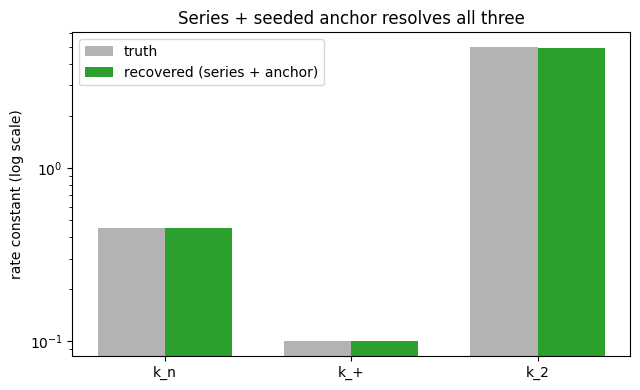

In [5]:
series = fib.simulate_concentration_series(with_anchor=True, seed=0)  # balanced regime
truth = {"k_n": fib._BALANCED_TRUTH.k_n, "k_+": fib._BALANCED_TRUTH.k_plus, "k_2": fib._BALANCED_TRUTH.k_2}

no_anchor  = fib.resolve_series(series, use_anchor=False, steps=1200)
with_anchor = fib.resolve_series(series, use_anchor=True,  steps=1500)

print("concentration series ALONE (no seeded anchor):")
print(f"   identifiable = {no_anchor.identifiable}   cond = {no_anchor.cond_number:.3g}")
print("   -> the gauge is concentration-independent; the series cannot separate the individuals.\n")
print("concentration series + a SEEDED elongation anchor (the Meisl discipline):")
print(f"   identifiable = {with_anchor.identifiable}   cond = {with_anchor.cond_number:.3g}")
print(f"   recovered:  k_n={with_anchor.k_n:.3g}  k_+={with_anchor.k_plus:.3g}  k_2={with_anchor.k_2:.3g}")
print(f"   truth:      k_n={truth['k_n']:.3g}  k_+={truth['k_+']:.3g}  k_2={truth['k_2']:.3g}")

assert no_anchor.identifiable is False                                   # series alone: degenerate
assert with_anchor.identifiable is True                                  # + anchor: resolved
for got, tru in ((with_anchor.k_n, truth['k_n']), (with_anchor.k_plus, truth['k_+']), (with_anchor.k_2, truth['k_2'])):
    assert abs(got - tru)/tru < 0.25                                     # 0 confident-wrong

fig, ax = plt.subplots(figsize=(6.5,4))
labels = ['k_n','k_+','k_2']; x = np.arange(3)
tvals = [truth['k_n'],truth['k_+'],truth['k_2']]; rvals = [with_anchor.k_n,with_anchor.k_plus,with_anchor.k_2]
ax.bar(x-0.18, tvals, 0.36, label='truth', color='0.7')
ax.bar(x+0.18, rvals, 0.36, label='recovered (series + anchor)', color='C2')
ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('rate constant (log scale)'); ax.set_title('Series + seeded anchor resolves all three'); ax.legend()
fig.tight_layout()

## What NUDGE will and will NOT claim (the honesty record — `NUDGE-LIM-021`)

- **From a single curve** it reports only the composites **κ, λ** and *proves* (measured
  Fisher curvature, cond → ∞) that the three individual constants are non-identifiable. It
  **never** emits a false-precise $k_n, k_+, k_2$ — the classic aggregation-kinetics
  overfitting trap.
- **A concentration series alone** cannot break the gauge (measured: still degenerate);
  resolving the individuals needs a **seeded anchor** (or a direct filament-number readout).
- **Inhibitor attribution** distinguishes end / surface / nucleus binders from the composite
  shifts — but a **global monomer-sequestering binder** scales κ and λ together *just like* an
  end binder, so that case is reported as "elongation OR monomer-sequestration", not
  over-claimed.
- The identifiability verdict keys on a **flat (zero-curvature) direction**, not the raw
  condition number (the *sloppiness* caveat: a sloppy-but-identifiable spectrum has a large
  *finite* cond, distinct from the genuine zero of the gauge).

Real-data validation (a published Aβ42 AmyloFit concentration series) is a later
`needs_data` gate; the equations + synthetic round-trip are the deliverable here.